## Experiment 6: Mxixng Vessels 

### This notebook contains all the coding for the graphs of this experiment. 


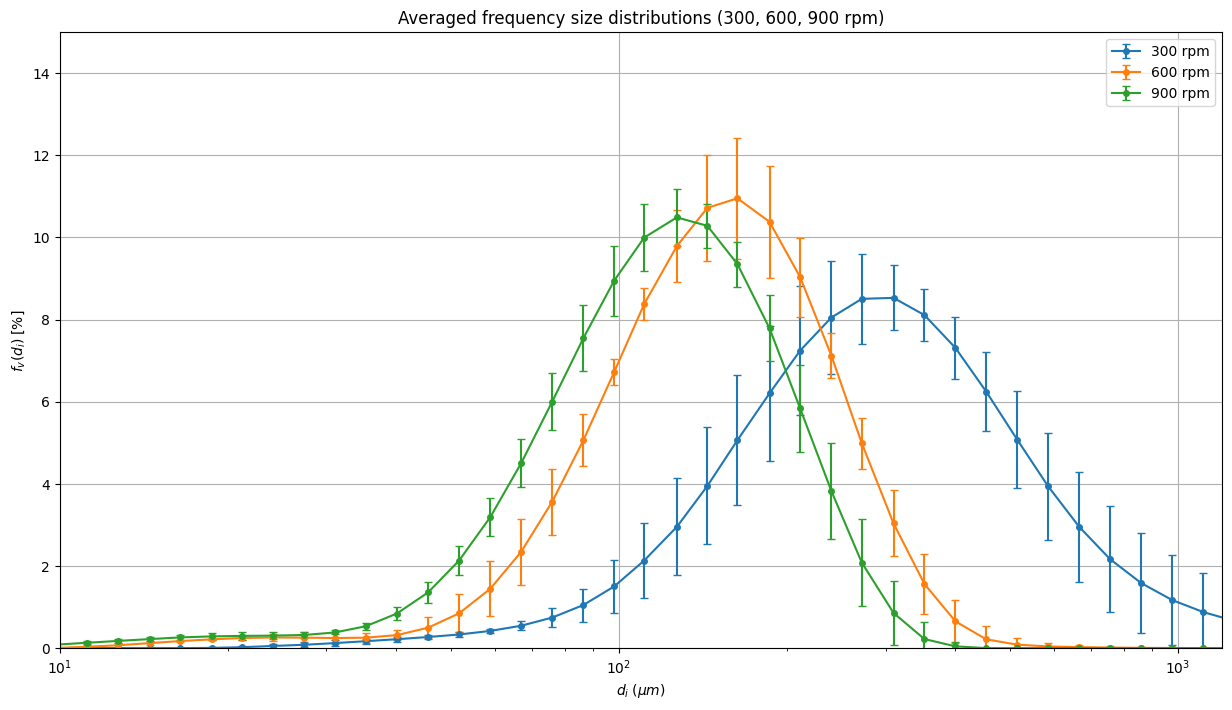

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Averaged frequency size distributions across times for 300, 600, 900 rpm (LOG x-scale)
# Changed to use per-point error bars (no shaded fill)

def load_and_clean(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.replace('[^A-Za-z0-9]+', '', regex=True)
    if 'Size' in df.columns:
        df.sort_values(by='Size', inplace=True)
    return df

paths = {"300":"Data300.csv","600":"Data600.csv","900":"Data900.csv"}
time_cols = ['t5','t10','t15','t20','t25','t30']

plt.figure(figsize=(15, 8))
for label, path in paths.items():
    try:
        df = load_and_clean(path)
    except FileNotFoundError:
        print(f"File {path} not found, skipping.")
        continue
    present = [c for c in time_cols if c in df.columns]
    if not present:
        continue
    t_vals = df[present]
    t_avg = t_vals.mean(axis=1)
    t_std = t_vals.std(axis=1)
    x = df['Size']
    # plot mean with error bars at each point
    plt.errorbar(x, t_avg, yerr=t_std, fmt='o-', linewidth=1.5, markersize=4, capsize=3, label=f"{label} rpm")

plt.xlabel(r"$d_i\;(\mu m)$")
plt.ylabel(r"$f_v(d_i)\;[\%]$")
plt.title('Averaged frequency size distributions (300, 600, 900 rpm)')
plt.xscale('log')
plt.xlim(10, 1200)
plt.ylim(0, 15)
plt.grid(True)
plt.legend()
plt.savefig("Exp_6_1_averaged_log.png", dpi=150, bbox_inches='tight')
plt.show()


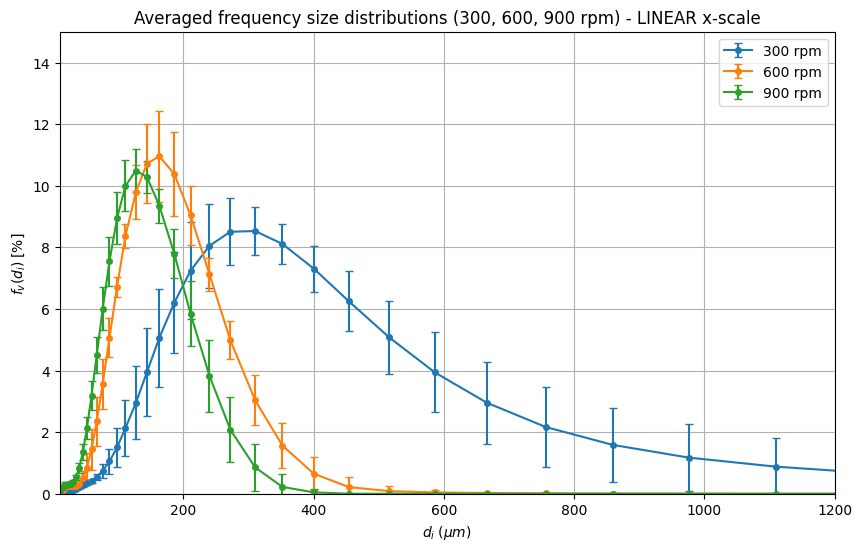

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Averaged frequency size distributions across times for 300, 600, 900 rpm (LINEAR x-scale)
# Changed to use per-point error bars (no shaded fill)

def load_and_clean(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.replace('[^A-Za-z0-9]+', '', regex=True)
    if 'Size' in df.columns:
        df.sort_values(by='Size', inplace=True)
    return df

paths = {"300":"Data300.csv","600":"Data600.csv","900":"Data900.csv"}
time_cols = ['t5','t10','t15','t20','t25','t30']

plt.figure(figsize=(10, 6))
for label, path in paths.items():
    try:
        df = load_and_clean(path)
    except FileNotFoundError:
        print(f"File {path} not found, skipping.")
        continue
    present = [c for c in time_cols if c in df.columns]
    if not present:
        continue
    t_vals = df[present]
    t_avg = t_vals.mean(axis=1)
    t_std = t_vals.std(axis=1)
    x = df['Size']
    # plot mean with error bars at each point
    plt.errorbar(x, t_avg, yerr=t_std, fmt='o-', linewidth=1.5, markersize=4, capsize=3, label=f"{label} rpm")

plt.xlabel(r"$d_i\;(\mu m)$")
plt.ylabel(r"$f_v(d_i)\;[\%]$")
plt.title('Averaged frequency size distributions (300, 600, 900 rpm) - LINEAR x-scale')
# linear x-scale (default)
plt.xlim(10, 1200)
plt.ylim(0, 15)
plt.grid(True)
plt.legend()
plt.savefig("Exp_6_2_averaged_linear.png", dpi=150, bbox_inches='tight')
plt.show()


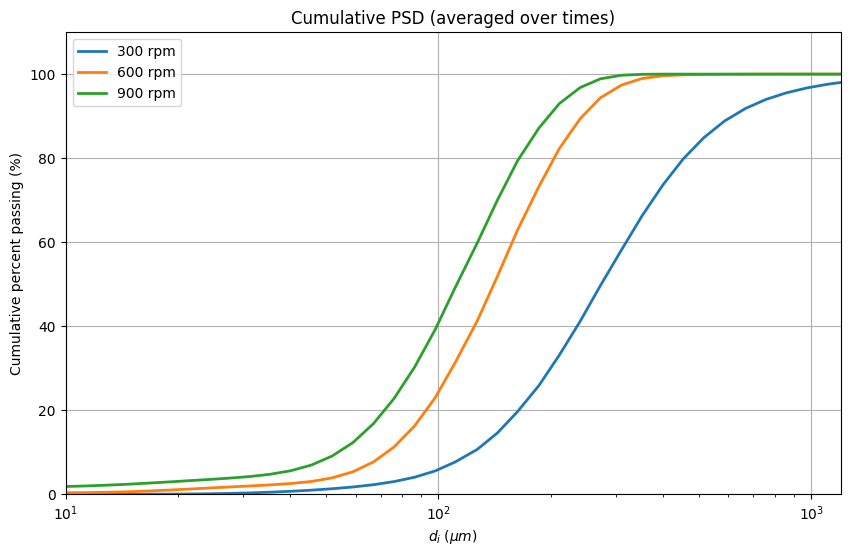

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Cumulative PSDs computed from averaged t-values (300 / 600 / 900)

def load_trim(path):
    df = pd.read_csv(path)

    # Clean column names
    df.columns = df.columns.str.replace('[^A-Za-z0-9]+', '', regex=True)

    # Find size column robustly
    size_cols = [c for c in df.columns if c.lower().startswith('size')]
    if not size_cols:
        raise ValueError("No Size column found after cleaning")

    size_col = size_cols[0]

    # Sort by particle size
    df.sort_values(by=size_col, inplace=True)

    return df, size_col


paths = {
    "300": "Data300.csv",
    "600": "Data600.csv",
    "900": "Data900.csv"
}

time_cols = ['t5', 't10', 't15', 't20', 't25', 't30']

plt.figure(figsize=(10, 6))

for label, path in paths.items():
    try:
        df, size_col = load_trim(path)
    except (FileNotFoundError, ValueError) as e:
        print(f"Skipping {path}: {e}")
        continue

    # Use only time columns that actually exist
    present = [c for c in time_cols if c in df.columns]
    if not present:
        print(f"No time columns found in {path}")
        continue

    # Average t-values row-wise
    t_avg = df[present].mean(axis=1)

    # Cumulative sum (convert to NumPy to avoid pandas indexing issues)
    cum = np.cumsum(t_avg.to_numpy())

    if cum.size == 0:
        continue

    # Normalize to cumulative percent passing
    if cum[-1] != 0:
        cum_pct = cum / cum[-1] * 100
    else:
        cum_pct = np.zeros_like(cum)

    plt.plot(
        df[size_col],
        cum_pct,
        '-',
        linewidth=2,
        label=f"{label} rpm"
    )

plt.xscale('log')
plt.xlabel(r"$d_i\;(\mu m)$")
plt.ylabel("Cumulative percent passing (%)")
plt.title("Cumulative PSD (averaged over times)")
plt.xlim(10, 1200)
plt.ylim(0, 110)
plt.grid(True)
plt.legend()

plt.savefig(
    "Exp_6_3_cumulative_averaged.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


In [83]:
import pandas as pd
import numpy as np

# Compute distribution statistics (Mean, Std, CV, D10/D50/D90) from averaged t-values

def distribution_stats(df, time_cols):
    present = [c for c in time_cols if c in df.columns]
    if not present:
        return None
    t_avg = df[present].mean(axis=1)
    sizes = df['Size'].values
    w = t_avg.values
    if w.sum() == 0:
        return None
    w_norm = w / w.sum()
    mean = (w_norm * sizes).sum()
    variance = (w_norm * (sizes - mean)**2).sum()
    std = np.sqrt(variance)
    cumsum = np.cumsum(w_norm)
    d10 = np.interp(0.10, cumsum, sizes)
    d50 = np.interp(0.50, cumsum, sizes)
    d90 = np.interp(0.90, cumsum, sizes)
    return {"Mean":mean, "Std":std, "CV":std/mean, "D10":d10, "D50":d50, "D90":d90}

paths = {"300":"Data300.csv","600":"Data600.csv","900":"Data900.csv"}
time_cols = ['t5','t10','t15','t20','t25','t30']
rows = []
for label, path in paths.items():
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        rows.append({"RPM":label, "Mean":None})
        continue
    df.columns = df.columns.str.replace('[^A-Za-z0-9]+', '', regex=True)
    if 'Size' in df.columns:
        df.sort_values(by='Size', inplace=True)
    stats = distribution_stats(df, time_cols)
    if stats:
        stats["RPM"] = label
        rows.append(stats)
    else:
        rows.append({"RPM":label, "Mean":None})
stats_df = pd.DataFrame(rows)
print(stats_df)


         Mean         Std        CV         D10         D50         D90  RPM
0  366.524888  295.305050  0.805689  123.645779  273.620276  617.212552  300
1  160.918473   75.185961  0.467230   72.902364  141.014534  244.026750  600
2  127.279742   61.177507  0.480654   53.924286  112.176710  198.265331  900


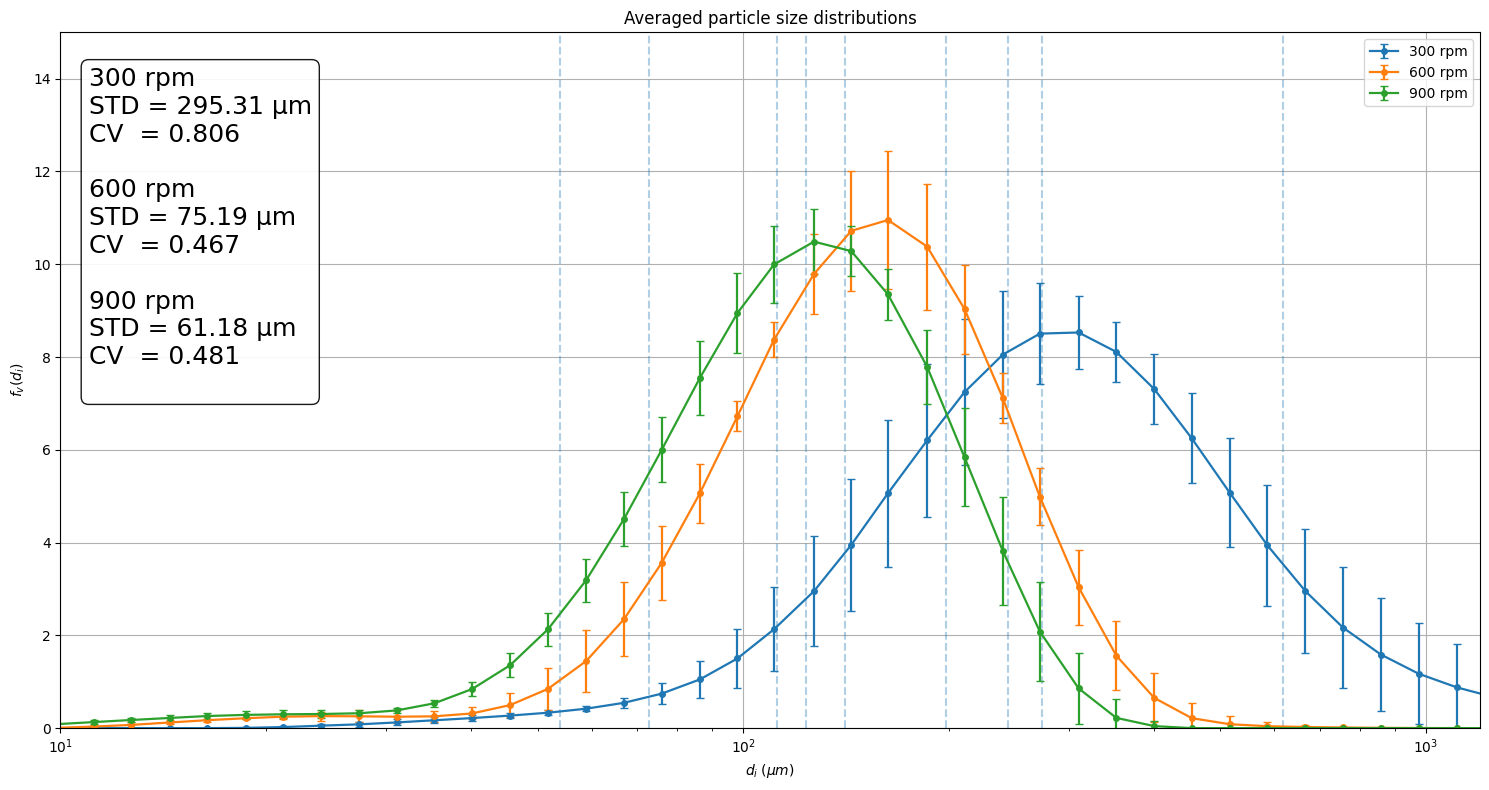

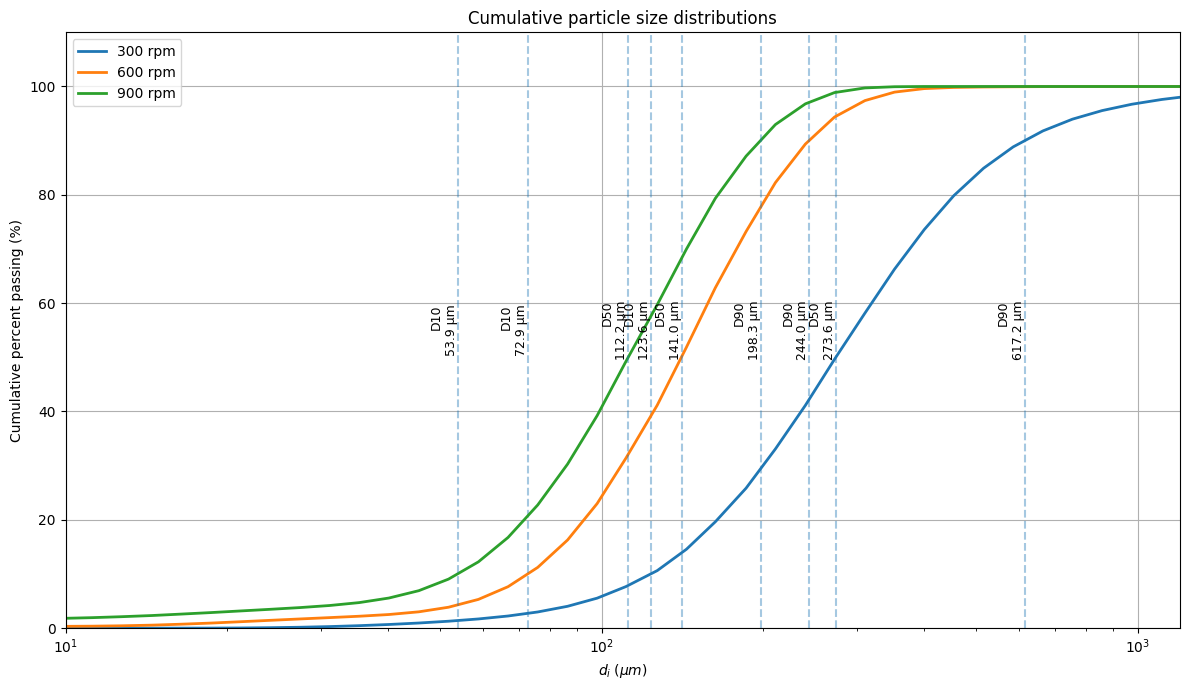

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ====================================================
# Helper functions
# ====================================================
def load_and_clean(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.replace('[^A-Za-z0-9]+', '', regex=True)
    df.sort_values(by='Size', inplace=True)
    return df

def compute_stats(df, time_cols):
    t_avg = df[time_cols].mean(axis=1).values
    sizes = df['Size'].values

    weights = t_avg / t_avg.sum()
    cdf = np.cumsum(weights)

    return {
        "Mean": np.sum(weights * sizes),
        "STD": np.sqrt(np.sum(weights * (sizes - np.sum(weights * sizes))**2)),
        "CV": np.sqrt(np.sum(weights * (sizes - np.sum(weights * sizes))**2)) /
              np.sum(weights * sizes),
        "D10": np.interp(0.10, cdf, sizes),
        "D50": np.interp(0.50, cdf, sizes),
        "D90": np.interp(0.90, cdf, sizes),
    }

# ====================================================
# Inputs
# ====================================================
paths = {
    "300 rpm": "Data300.csv",
    "600 rpm": "Data600.csv",
    "900 rpm": "Data900.csv",
}

time_cols = ['t5', 't10', 't15', 't20', 't25', 't30']
all_stats = {}

# ====================================================
# GRAPH 1 — Averaged PSD (log scale)
# ====================================================
plt.figure(figsize=(15, 8))

legend_text = []

for label, path in paths.items():
    df = load_and_clean(path)
    present = [c for c in time_cols if c in df.columns]

    t_avg = df[present].mean(axis=1)
    t_std = df[present].std(axis=1)

    plt.errorbar(
        df['Size'], t_avg,
        yerr=t_std,
        fmt='o-', linewidth=1.6, capsize=3,
        markersize=4, label=label
    )

    stats = compute_stats(df, present)
    all_stats[label] = stats

    # --- D-values (vertical markers) ---
    for d in [stats["D10"], stats["D50"], stats["D90"]]:
        plt.axvline(d, linestyle='--', alpha=0.35)

    # --- build left legend text ---
    legend_text.append(
        f"{label}\n"
        f"STD = {stats['STD']:.2f} μm\n"
        f"CV  = {stats['CV']:.3f}\n"
    )

plt.xscale('log')
plt.xlim(10, 1200)
plt.ylim(0, 15)
plt.xlabel(r"$d_i\;(\mu m)$")
plt.ylabel(r"$f_v(d_i)$")
plt.title("Averaged particle size distributions")
plt.grid(True)

# ---- main legend (lines) ----
plt.legend(loc="upper right")

# ---- STD & CV box (left side) ----
plt.text(
    0.02, 0.95,
    "\n".join(legend_text),
    transform=plt.gca().transAxes,
    fontsize=18,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

plt.tight_layout()
plt.show()

# ====================================================
# GRAPH 3 — Cumulative PSD
# ====================================================
plt.figure(figsize=(12, 7))

for label, path in paths.items():
    df = load_and_clean(path)
    present = [c for c in time_cols if c in df.columns]

    t_avg = df[present].mean(axis=1).values
    cumulative = np.cumsum(t_avg)
    cumulative = cumulative / cumulative[-1] * 100

    plt.plot(df['Size'], cumulative, linewidth=2, label=label)

    stats = all_stats[label]

    for d, name in zip(
        [stats["D10"], stats["D50"], stats["D90"]],
        ["D10", "D50", "D90"]
    ):
        plt.axvline(d, linestyle='--', alpha=0.4)
        plt.text(
            d, 55,
            f"{name}\n{d:.1f} μm",
            rotation=90,
            ha='right', va='center', fontsize=9
        )

plt.xscale('log')
plt.xlim(10, 1200)
plt.ylim(0, 110)
plt.xlabel(r"$d_i\;(\mu m)$")
plt.ylabel("Cumulative percent passing (%)")
plt.title("Cumulative particle size distributions")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

